# How a simple regression changes in the Bambi rewrite (PR #1002)

Bambi is being rewritten in [bambinos/bambi#1002](https://github.com/bambinos/bambi/pull/1002),
a ~50-commit draft by @tomicapretto that refactors families, defaults, and the PyMC backend.
This notebook fits the **same simple linear regression** twice to show what a user actually sees change:

- **Before**: Bambi 0.20.0, the current PyPI release (installed in `.venv-old`)
- **After**: the rewrite branch at commit [`3fc7196`](https://github.com/bambinos/bambi/pull/1002)
  (installed in `.venv-new`, which also runs this notebook's kernel)

Both environments share the modern ecosystem (PyMC 6, ArviZ 1.3, so `fit()` already returns an
`xarray.DataTree` in both) — the differences below are the rewrite's own.

**TL;DR — what changes for `y ~ x`:**

| | Bambi 0.20.0 | Rewrite (PR #1002) |
|---|---|---|
| Model internals | `model.components`, `model.response_component`, ... | one dict: `model.parameters` |
| Sampled intercept | `Intercept` directly | `Intercept_centered` (predictors centered), `Intercept` recovered |
| Result groups | `posterior`, `sample_stats`, `observed_data` | adds `constant_data` |
| `fit()` default sampler | `inference_method="pymc"` | `inference_method=None` (backend decides) |
| Custom links | `bmb.Link(name, link, linkinv, linkinv_backend)` | `bmb.Link(name, link, inverse_link)` |
| Estimates | — | unchanged (see final figure) |

> **Caveat**: the branch is a moving draft. At `3fc7196` it does not even import without a one-line
> patch (a Python-2-style `except RuntimeError, ValueError:` at `bambi/backend/pymc/model.py:557`),
> which we apply during setup. Details in this directory's README.


## Setup

Simulate a dataset once and share it with both environments through a CSV,
so the two fits see identical data: $y = 1 + 2x + \varepsilon$, $\varepsilon \sim N(0, 0.5)$.


In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(1234)
x = rng.normal(size=100)
df = pd.DataFrame({"x": x, "y": 1 + 2 * x + rng.normal(scale=0.5, size=100)})
df.to_csv("shared_data.csv", index=False)
df.head()

,x,y
0,-1.603837,-1.080711
1,0.064100,1.209007
2,0.740891,2.898672
3,0.152619,0.515184
4,0.863744,3.232780


## Before: Bambi 0.20.0

The cell below runs in the **old** environment (`%%script .venv-old/bin/python`), so its output is
genuinely produced by the released Bambi. The workflow is the classic one: build the model, look at
`model.components`, fit, inspect.


In [2]:
%%script .venv-old/bin/python
import warnings; warnings.filterwarnings("ignore")
import arviz as az
import bambi as bmb
import pandas as pd

print("bambi", bmb.__version__)

df = pd.read_csv("shared_data.csv")
model = bmb.Model("y ~ x", df)
print()
print(model)

print("\n--- model internals ---")
print("model.components:", {k: type(v).__name__ for k, v in model.components.items()})
print("model.response_component:", type(model.response_component).__name__)

# cores=1: the %%script cell feeds code via stdin, which breaks multiprocess spawn
results = model.fit(draws=500, chains=4, cores=1, progressbar=False, random_seed=1234)

print("\n--- results ---")
print("type:", type(results).__name__)
print("groups:", list(results.children))
print("posterior variables:", list(results.posterior.data_vars))
print()
print(az.summary(results))

results.posterior.to_dataset().to_dataframe()[["Intercept", "x", "sigma"]].to_csv("posterior_old.csv", index=False)

bambi 0.20.0


       Formula: y ~ x
        Family: gaussian
          Link: mu = identity
  Observations: 100
   

     Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.2903

, sigma: 5.858)
            x ~ Normal(mu: 0.0, sigma: 5.1948)
        
        Auxiliary parameters


            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.3282)

--- model internals ---
model.components:

...

posterior variables: ['sigma', 'Intercept', 'x']



            mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
sigma      0.52

8  0.038     0.47     0.59     2518     1575  1.00   0.00076  0.00054
Intercept  1.033  0.052     0.

95      1.1     3005     1420  1.00   0.00095  0.00067
x          2.028  0.047        2      2.1    

 3200     1451  1.00   0.00084  0.00063


Note what PyMC sampled: `[sigma, Intercept, x]` — the intercept is a direct parameter of the
model, and the returned tree has three groups.

## After: the rewrite

The same workflow, run natively in the rewrite environment.


In [3]:
import warnings; warnings.filterwarnings("ignore")
import arviz as az
import bambi as bmb
import pandas as pd

print("bambi", bmb.__version__)

df = pd.read_csv("shared_data.csv")
model = bmb.Model("y ~ x", df)
model

bambi 0.20.1.dev50+g3fc7196aa.d20260822


       Formula: y ~ x
        Family: gaussian
          Link: mu = identity
  Observations: 100
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 1.2903, sigma: 5.858)
            x ~ Normal(mu: 0.0, sigma: 5.1948)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.3282)

The model repr and the automatic priors are **identical** — the auto-scaling logic
(`Intercept ~ Normal(1.29, 5.86)`, `x ~ Normal(0, 5.19)`, `sigma ~ HalfStudentT(4, 2.33)`)
survives the rewrite unchanged.

What changed is the object model underneath. The zoo of component attributes is gone,
replaced by a single `parameters` dict:


In [4]:
print("model.parameters:", {k: type(v).__name__ for k, v in model.parameters.items()})
for attr in ["components", "response_component", "constant_components", "distributional_components"]:
    print(f"model.{attr}:", "still exists" if hasattr(model, attr) else "removed")

model.parameters: {'mu': 'ConditionalParameter', 'sigma': 'MarginalParameter'}
model.components: removed
model.response_component: removed
model.constant_components: removed
model.distributional_components: removed


In [5]:
results = model.fit(draws=500, chains=4, progressbar=False, random_seed=1234)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [sigma, x, Intercept_centered]


Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.


Two differences in the sampling log and output:

1. PyMC now samples `[sigma, x, Intercept_centered]` — the rewrite **centers predictors by
   default** in the actual computation graph and recovers `Intercept` on the original scale as a
   derived variable. (0.20.0 already had a `center_predictors` argument, but the sampled
   parametrization did not change; in the rewrite it does.) Centering decorrelates the intercept
   from the slopes, which generally helps NUTS.
2. The returned `DataTree` gains a `constant_data` group.


In [6]:
print("groups:", list(results.children))
print("posterior variables:", list(results.posterior.data_vars))
print()
az.summary(results)

groups: ['posterior', 'sample_stats', 'observed_data', 'constant_data']
posterior variables: ['sigma', 'x', 'Intercept_centered', 'Intercept']



,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,0.528,0.038,0.47,0.59,2859,1549,1.00,0.00073,0.00058
x,2.026,0.047,1.9,2.1,3154,1612,1.00,0.00084,0.0006
Intercept_centered,1.289,0.053,1.2,1.4,3073,1734,1.00,0.00096,0.00068
Intercept,1.031,0.054,0.95,1.1,3045,1679,1.00,0.00098,0.0007


## Same posterior, new plumbing

The parametrization changed but the model did not: the posteriors from both versions line up.


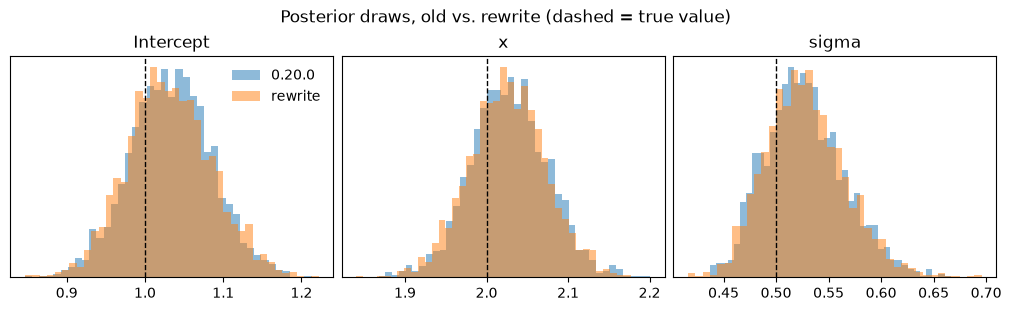

In [7]:
import matplotlib.pyplot as plt

post_old = pd.read_csv("posterior_old.csv")
post_new = results.posterior

fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
params = [("Intercept", 1.0), ("x", 2.0), ("sigma", 0.5)]
for ax, (name, truth) in zip(axes, params):
    ax.hist(post_old[name].values.ravel(), bins=40, density=True, alpha=0.5, label="0.20.0")
    ax.hist(post_new[name].values.ravel(), bins=40, density=True, alpha=0.5, label="rewrite")
    ax.axvline(truth, color="k", ls="--", lw=1)
    ax.set_title(name)
    ax.set_yticks([])
axes[0].legend(frameon=False)
fig.suptitle("Posterior draws, old vs. rewrite (dashed = true value)");

## API diffs beyond this model

`fit()` keeps its shape; the one visible change is that the default `inference_method` is now
`None`, leaving backend selection to the (new, pluggable) backend layer:


In [8]:
%%script .venv-old/bin/python
import bambi as bmb, inspect
print("0.20.0  Model.fit", inspect.signature(bmb.Model.fit))
print("0.20.0  Link     ", inspect.signature(bmb.Link.__init__))

0.20.0  Model.fit (self, draws=1000, tune=1000, discard_tuned_samples=True, omit_offsets=True, inclu

de_mean=None, include_response_params=False, inference_method='pymc', init='auto', n_init=50000, cha

ins=None, cores=None, random_seed=None, nuts=None, **kwargs)
0.20.0  Link      (self, name, link=Non

e, linkinv=None, linkinv_backend=None)


In [9]:
import inspect
print("rewrite Model.fit", inspect.signature(bmb.Model.fit))
print("rewrite Link     ", inspect.signature(bmb.Link.__init__))

rewrite Model.fit (self, draws=1000, tune=1000, discard_tuned_samples=True, omit_offsets=True, include_mean=None, include_response_params=False, inference_method=None, init='auto', n_init=50000, chains=None, cores=None, random_seed=None, nuts=None, **kwargs)
rewrite Link      (self, name, link=None, inverse_link=None)


The `Link` change reflects the deeper refactor: families are decoupled from PyMC/PyTensor,
so a custom link no longer needs both a NumPy inverse (`linkinv`) and a tensor inverse
(`linkinv_backend`) — just one `inverse_link` that operates on backend tensors:

```python
# 0.20.0
link = bmb.Link("my_logit", link=special.logit,
                linkinv=special.expit, linkinv_backend=bmb.math.sigmoid)

# rewrite
link = bmb.Link("my_logit", inverse_link=bmb.math.sigmoid)
```

## Takeaways

For a simple Gaussian regression, the rewrite is almost invisible on the surface — same formula,
same automatic priors, same posterior. The visible changes are a cleaner object model
(`parameters` instead of the component zoo), a better default parametrization (centered
predictors), and a `fit()` that delegates sampler choice to a pluggable backend. The breaking
changes concentrate in the extension points (custom links, families, internals-poking code), which
is where migration effort will go.
